In [108]:
import numpy as np
import matplotlib.pylab as plt

In [109]:
a = 0.0  
b = 2.0  

seed_value = 1903
rng  = np.random.default_rng(seed_value)

f = lambda x: (np.exp(x) - 1.0) / (np.exp(1.0) - 1.0)
phi = lambda x: 1.+ 1.58198*(x-1) + 0.790988*(x-1)**2 # use taylor expansion of f at midpoint of interval
fminusphi = lambda x: f(x) - phi(x)

Ifexakt = (np.exp(b) - b - np.exp(a) + a) / (np.exp(1.0) - 1.0)
Iphiexakt = -0.209008 * a - 2e-6 * a**2 - 0.263663 * a**3 + b * (0.209008 + 2e-6 * b + 0.263663 * b**2) 
# exact value of the analytically determinded integral of phi from a to b

Nmin = 2
Nmax = 1000
N = np.arange(Nmin, Nmax + 1)

In [110]:
def simpson(f, a, b, N):
  x, h = np.linspace(a, b, 2*int(N)+1, retstep=True)
  I = h/3.0 * sum(f(x[:-2:2]) + 4.0*f(x[1:-1:2]) + f(x[2::2]))
  return I

def mc(func, a, b, N, rng):
    """
    Monte-Carlo Quadrature
    """
    x = a + (b-a) * rng.random(size = N)
    I = (b-a)/float(N)*np.sum(f(x))
    return I
    
def mc_2(func, a, b, N, rng,phi, phiExact):
    """
    Monte-Carlo Quadrature using control variates
    phi is a function "similar" to func, we get it by taking the first terms of the taylor approximation of func
    """
    x = a + (b-a) * rng.random(size = N)
    sumx =  f(x) - phi(x)
    sumx = np.sum(sumx)
    I = (b-a)* (1/float(N)) * sumx + phiExact
    return I
  




In [111]:
res_simp = np.zeros((Nmax - Nmin + 1, 1))  # Results of Simpson-Rule
res_mc = np.zeros((Nmax - Nmin + 1, 1))  #  Results of Monte-Carlo Quadrature

res_mcvc = np.zeros((Nmax - Nmin + 1, 1))#  Results of Monte-Carlo Quadrature with Control Variates 

err_simp = np.zeros((Nmax - Nmin + 1, 1))  # error of Simpson-Rule
err_mc = np.zeros((Nmax - Nmin + 1, 1))  # error of  Monte-Carlo Quadrature
# Fehler der MC Quad. + Varianzkontrolle
err_mcvc = np.zeros((Nmax - Nmin + 1, 1))

# get errors and convergence rate
for i in range(1,len(N)+1):
    err_mc[i-1] = np.abs(mc(f, a, b, i, rng)-Ifexakt)
    err_simp[i-1] = np.abs(simpson(f, a, b, i)- Ifexakt)
    err_mcvc[i-1] = np.abs(mc_2(f, a, b, i, rng,phi, Iphiexakt) - Ifexakt)


In [112]:
convergence_simp = np.polyfit(np.log(N), np.log(err_simp),1)[0]
convergence_mc = np.polyfit(np.log(N), np.log(err_mc),1)[0]
convergence_mcvc = np.polyfit(np.log(N[-200:]), np.log(err_mcvc[-200:]), 1)[0]

print('Simpson Quadratur Konvergenzrate:' + str(-convergence_simp))
print('Monte-Carlo Quadratur Konvergenzrate:' + str(-convergence_mc))
print('Monte-Carlo + Varianzkontrolle Quadratur Konvergenzrate: '  + str(-convergence_mcvc))



Simpson Quadratur Konvergenzrate:[4.06972125]
Monte-Carlo Quadratur Konvergenzrate:[0.48452925]
Monte-Carlo + Varianzkontrolle Quadratur Konvergenzrate: [1.2117672]


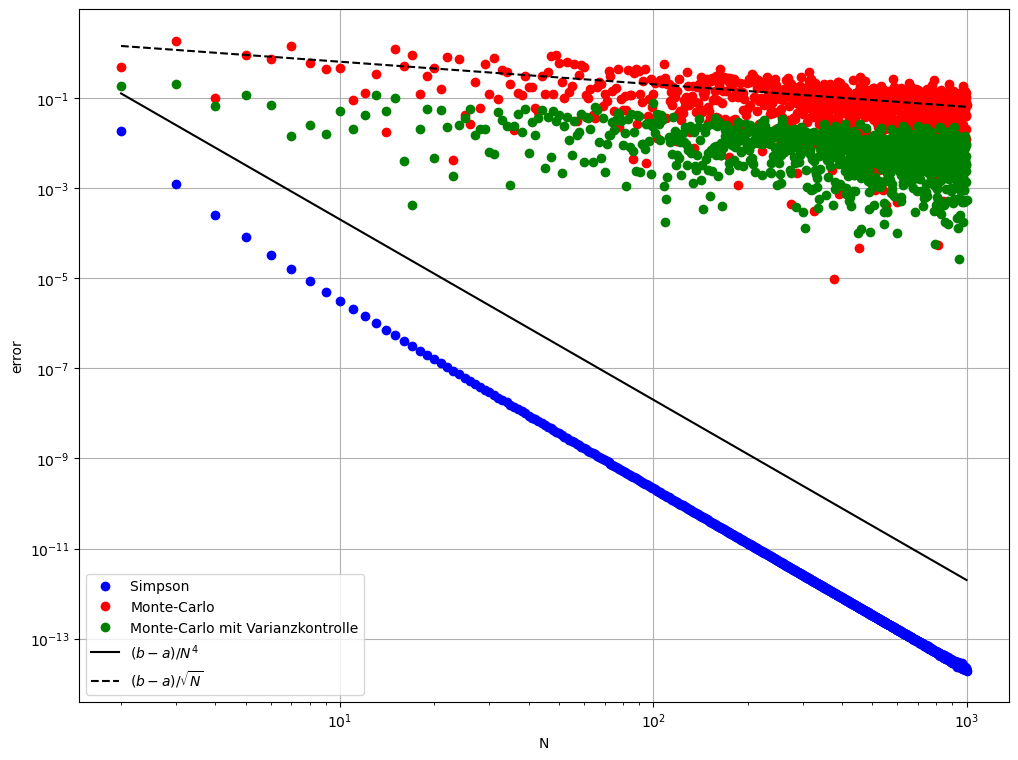

In [113]:
# Plot der Konvergenzstudie
plt.figure(figsize=(12, 9))
plt.loglog(N, err_simp, 'bo', label='Simpson ')
plt.loglog(N, err_mc, 'ro', label='Monte-Carlo')
plt.loglog(N, err_mcvc, 'go', label='Monte-Carlo mit Varianzkontrolle')
plt.loglog(N, (b-a)/N**4, 'k-', label=r'$(b-a)/N^4$')
plt.loglog(N, (b-a)/np.sqrt(N), 'k--', label=r'$(b-a)/\sqrt{N}$')
plt.xlabel('N')
plt.ylabel('error')
plt.legend(loc=3)
plt.grid()


p_simp = np.zeros((2,2))  # Simpson
p_mc = np.zeros((2,2)) # Monte-Carlo
p_mcvc = np.zeros((2,2))
